**Customer Segmentation Analysis**

Name : Sudarshan Bharat Patil

IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


DATA VALIDATION

In [ ]:
assert df.isnull().sum().sum() == 0, "Dataset contains missing values"
df.drop_duplicates(inplace=True)

FEATURE ENGINEERING

In [ ]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

In [ ]:
df['Income_to_Age_Ratio'] = df['Annual_Income'] / df['Age']
df['Spending_Intensity'] = df['Spending_Score'] / df['Annual_Income']

FEATURE SELECTION

In [ ]:
numeric_features = ['Age', 'Annual_Income', 'Spending_Score',
                    'Income_to_Age_Ratio', 'Spending_Intensity']

categorical_features = ['Gender']

PREPROCESSING PIPELINE

In [ ]:
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

MODEL SELECTION

In [ ]:
X_processed = preprocessor.fit_transform(df)

wcss = []
silhouette_scores = []

K_RANGE = range(2, 11)

for k in K_RANGE:
    model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = model.fit_predict(X_processed)

    wcss.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, labels))

VISUALIZATION: ELBOW METHOD

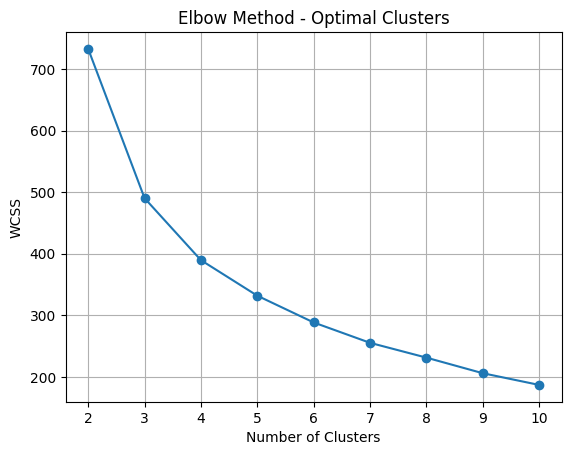

In [ ]:
plt.figure()
plt.plot(K_RANGE, wcss, marker='o')
plt.title("Elbow Method - Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid()
plt.show()


 SILHOUETTE SCORE

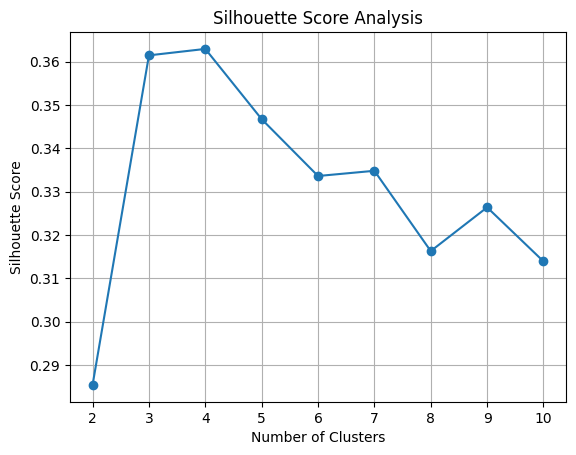

In [ ]:
plt.figure()
plt.plot(K_RANGE, silhouette_scores, marker='o')
plt.title("Silhouette Score Analysis")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

FINAL MODEL

In [ ]:
optimal_k = K_RANGE[np.argmax(silhouette_scores)]

kmeans_final = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    random_state=42,
    n_init=20
)

df['Cluster'] = kmeans_final.fit_predict(X_processed)

DIMENSIONALITY REDUCTION FOR VISUALIZATION

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA


pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_processed)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
df['PCA3'] = X_pca[:, 2]

CLUSTER VISUALIZATION

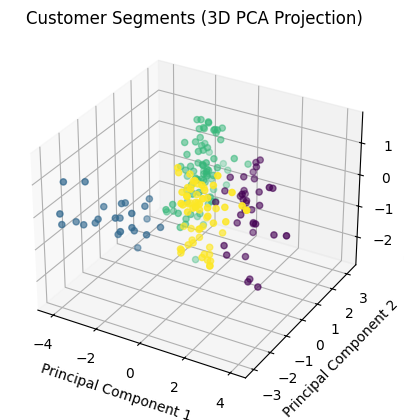

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['PCA1'],
    df['PCA2'],
    df['PCA3'],
    c=df['Cluster'],
)

ax.set_title("Customer Segments (3D PCA Projection)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.show()

CLUSTER PROFILING

In [ ]:
cluster_profile = df.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual_Income': ['mean', 'min', 'max'],
    'Spending_Score': ['mean', 'min', 'max'],
    'Income_to_Age_Ratio': 'mean',
    'Spending_Intensity': 'mean'
}).round(2)

print("\n=== CLUSTER PROFILE ===")
print(cluster_profile)


=== CLUSTER PROFILE ===
           Age         Annual_Income          Spending_Score          \
          mean min max          mean min  max           mean min max   
Cluster                                                                
0        39.72  19  59         87.42  67  137          18.39   1  40   
1        25.25  18  35         24.92  15   39          76.04  39  99   
2        50.51  20  70         46.39  16   79          40.57   3  61   
3        29.29  18  40         76.11  46  137          70.30  40  97   

        Income_to_Age_Ratio Spending_Intensity  
                       mean               mean  
Cluster                                         
0                      2.37               0.22  
1                      1.03               3.29  
2                      0.95               0.88  
3                      2.65               0.94  


 SEGMENT LABELING

In [ ]:
def label_segment(row):
    if row['Annual_Income'] > 70 and row['Spending_Score'] > 70:
        return "Premium Customers"
    elif row['Annual_Income'] > 70 and row['Spending_Score'] < 40:
        return "Cautious High Income"
    elif row['Annual_Income'] < 40 and row['Spending_Score'] > 70:
        return "Impulse Buyers"
    elif row['Annual_Income'] < 40 and row['Spending_Score'] < 40:
        return "Budget Customers"
    else:
        return "Standard Customers"

df['Segment'] = df.apply(label_segment, axis=1)

 SEGMENT DISTRIBUTION

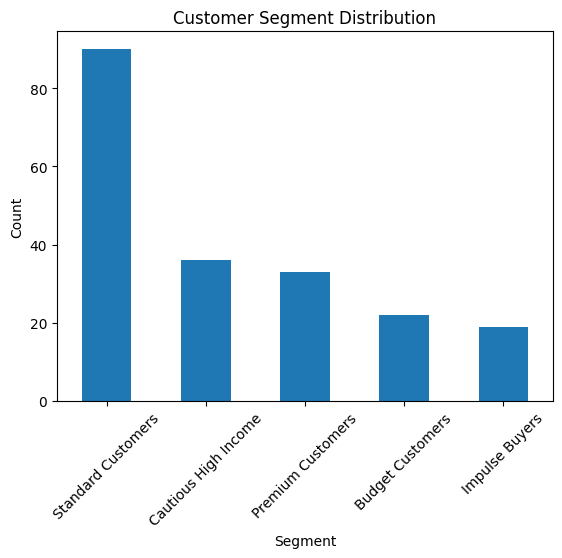

In [ ]:
plt.figure()
df['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

SAVING THE DATASET

In [ ]:
df.to_csv("customer_segments_output.csv", index=False)

print("\nPipeline execution complete. Segmented dataset saved.")


Pipeline execution complete. Segmented dataset saved.
